---
Author: The Tuan Trinh \
Date: 01/06/2026
---

In [1]:
import os
import platform
print("=" * 100)
print("OS Name:", os.name)
print("System:", platform.system())
print("Release:", platform.release())
print("Machine:", platform.machine())
print("Processor:", platform.processor())
print("Platform:", platform.platform())

print("\nEnvironment Variables (sample):")
for key, value in list(os.environ.items())[:15]:
    print(f"{key} = {value}")

OS Name: nt
System: Windows
Release: 10
Machine: AMD64
Processor: Intel64 Family 6 Model 142 Stepping 12, GenuineIntel
Platform: Windows-10-10.0.26200-SP0

Environment Variables (sample):
ALLUSERSPROFILE = C:\ProgramData
APPDATA = C:\Users\Admin\AppData\Roaming
APPLICATION_INSIGHTS_NO_STATSBEAT = true
CHROME_CRASHPAD_PIPE_NAME = \\.\pipe\crashpad_9744_ZGSXKUMXDBQNQZJY
COMMONPROGRAMFILES = C:\Program Files\Common Files
COMMONPROGRAMFILES(X86) = C:\Program Files (x86)\Common Files
COMMONPROGRAMW6432 = C:\Program Files\Common Files
COMPUTERNAME = PMH
COMSPEC = C:\Windows\system32\cmd.exe
CONDA_DEFAULT_ENV = PMH
CONDA_EXE = C:\Users\Admin\miniconda3\Scripts\conda.exe
CONDA_PREFIX = C:\Users\Admin\miniconda3\envs\PMH
CONDA_PROMPT_MODIFIER = (PMH) 
CONDA_PYTHON_EXE = C:\Users\Admin\miniconda3\python.exe
CONDA_ROOT = C:\Users\Admin\miniconda3


In [2]:
platform.python_version()

'3.10.20'

# Lab 14 - Image Retrieval


In [1]:
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import io

url = "https://64.media.tumblr.com/2d2b8515e30477587db32e5906960193/tumblr_nhs39ksylA1tawn8uo1_1280.jpg"
resp = urllib.request.urlopen(url)
img = np.asarray(bytearray(resp.read()), dtype=np.uint8)
img_pil = Image.open(io.BytesIO(img))

gray = np.array(img_pil.convert('L'))

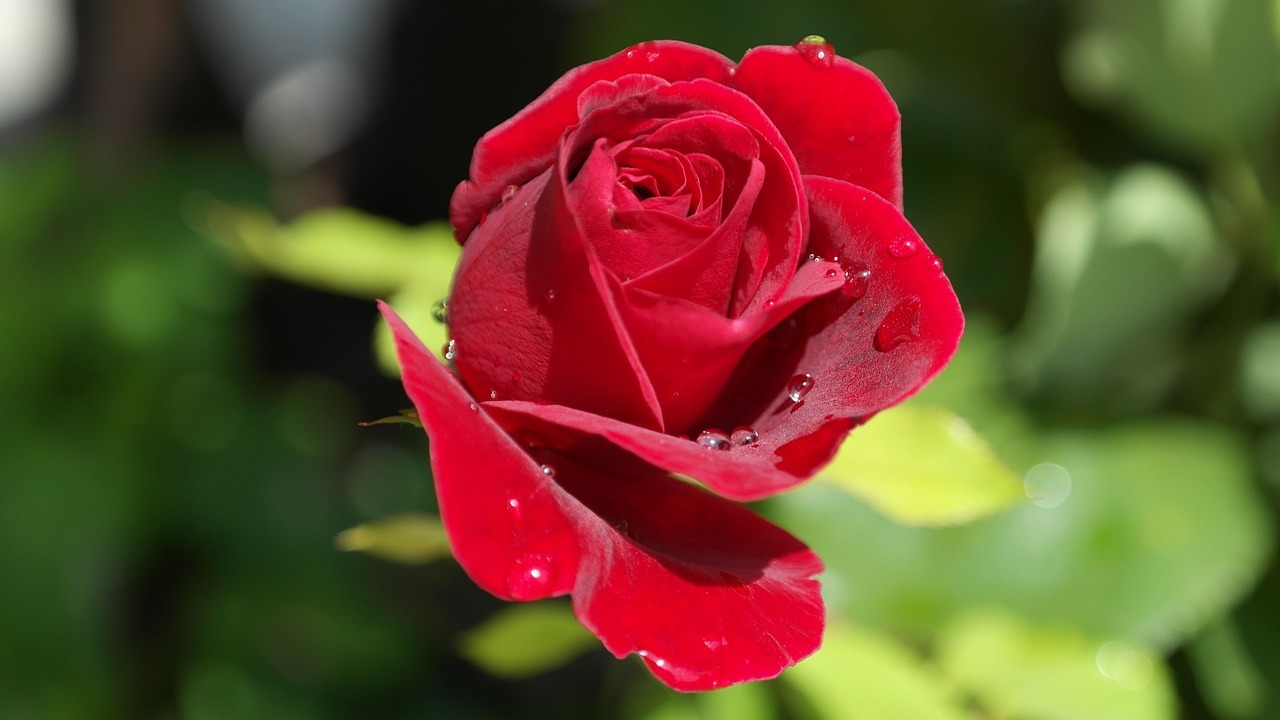

In [2]:
img_pil

In [3]:
img1 = gray.copy()
img2 = np.roll(gray, 50, axis=1)
img3 = np.fliplr(gray)

In [4]:
f1 = img1.flatten().astype(np.float32)
f2 = img2.flatten().astype(np.float32)
f3 = img3.flatten().astype(np.float32)

In [5]:
d12 = np.linalg.norm(f1-f2)
d13 = np.linalg.norm(f1-f3)

print("Original vs Shift =", d12)
print("Original vs Flip  =", d13)

Original vs Shift = 39465.137
Original vs Flip  = 78052.4


In [6]:
def get_hist(im):

    h = np.zeros(256)

    for p in im.flatten():
        h[p] += 1

    h /= h.sum()

    return h

h1 = get_hist(img1)
h2 = get_hist(img2)
h3 = get_hist(img3)

print("Original vs Shift:",
      np.linalg.norm(h1-h2))

print("Original vs Flip:",
      np.linalg.norm(h1-h3))

Original vs Shift: 0.0
Original vs Flip: 0.0


In [7]:
A = np.zeros((256,256),dtype=np.uint8)
A[:128,:] = 255

B = np.zeros((256,256),dtype=np.uint8)
B[:,::2] = 255

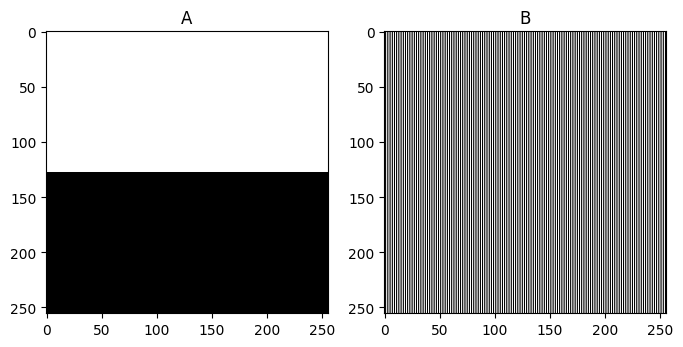

In [8]:
plt.figure(figsize=(8,4))

plt.subplot(121)
plt.imshow(A,cmap='gray')
plt.title("A")

plt.subplot(122)
plt.imshow(B,cmap='gray')
plt.title("B")

plt.show()

In [9]:
def local_hist(img):

    H,W = img.shape

    feats = []

    for r in range(2):
        for c in range(2):

            block = img[
                r*H//2:(r+1)*H//2,
                c*W//2:(c+1)*W//2
            ]

            hist = np.zeros(256)

            for p in block.flatten():
                hist[p] += 1

            hist /= hist.sum()

            feats.extend(hist)

    return np.array(feats)

fA = local_hist(A)
fB = local_hist(B)

print(np.linalg.norm(fA-fB))

1.4142135623730951
